## 海归策略

In [1]:
#获取数据
import tushare as ts
import pandas as pd
import os

def get_petrochina_stock_data(start_date, end_date):
    """
    获取中国石油股票历史行情数据并保存为CSV文件
    
    参数:
    start_date: 开始日期，格式为'YYYY-MM-DD'
    end_date: 结束日期，格式为'YYYY-MM-DD'
    """
    try:
        # 设置tushare的token，需要用户自己去tushare官网注册获取
        ts.set_token('598eb3c437b4143dde41a08f283e909b5cce0154bb923c346d4c6e58')
        
        # 初始化pro接口
        pro = ts.pro_api()
        
        # 中国石油的股票代码是601857.SH（沪市）
        stock_code = '601857.SH'
        
        # 获取日线数据
        df = pro.daily(ts_code=stock_code, start_date=start_date, end_date=end_date)
        
        if df.empty:
            print("没有获取到数据，请检查日期范围或股票代码")
            return
        
        # 数据处理：将日期转换为标准格式，并按日期排序
        df['trade_date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')
        df = df.sort_values('trade_date')
        
        # 重命名列名，使其更直观
        df = df.rename(columns={
            'ts_code': '股票代码',
            'trade_date': '交易日期',
            'open': '开盘价',
            'high': '最高价',
            'low': '最低价',
            'close': '收盘价',
            'pre_close': '前收盘价',
            'change': '涨跌额',
            'pct_chg': '涨跌幅(%)',
            'vol': '成交量(手)',
            'amount': '成交额(千元)'
        })
        
        # 保存为CSV文件，文件名为"中国石油_起始日期_结束日期.csv"
        filename = f"中国石油_{start_date.replace('-', '')}_{end_date.replace('-', '')}.csv"
        df.to_csv(filename, index=False, encoding='utf-8-sig')
        
        print(f"数据已成功保存到当前文件夹：{filename}")
        print(f"共获取到{len(df)}条记录")
        
    except Exception as e:
        print(f"获取数据时发生错误：{str(e)}")
        print("请确保已安装tushare库（pip install tushare）并正确设置了token")

if __name__ == "__main__":
    # 设置想要获取的日期范围
    start_date = '2020-01-01'
    end_date = '2023-12-31'
    
    # 调用函数获取数据
    get_petrochina_stock_data(start_date, end_date)
    

数据已成功保存到当前文件夹：中国石油_20200101_20231231.csv
共获取到728条记录


In [10]:
inputfile = '中国石油_20200101_20231231.csv'
outfile = '中国石油.csv'

try:
    # 打开原始文件和目标文件
    with open(inputfile, 'r', encoding='utf-8-sig') as input_file, \
         open(outfile, 'w', encoding='utf-8-sig') as output_file:
        
        # 逐行读取原始文件
        for line in input_file:
            # 去除行末的换行符和可能的空格
            line = line.strip()
            # 判断是否为空行
            if line:
                # 写入非空行到目标文件
                output_file.write(line + '\n')  # 确保此行缩进正确
    
    print(f'处理完成，已保存到 {outfile}')

except FileNotFoundError:
    print(f'错误：找不到文件 {inputfile}')
except Exception as e:
    print(f'处理过程中发生错误：{str(e)}')

处理完成，已保存到 中国石油.csv


## 数据读取

In [11]:
import pandas as pd
#数据文件
f = '中国石油.csv'
#读取数据
df = pd.read_csv(f,encoding='utf-8',parse_dates=True)
#重新命名列名
column_mapping = {
    '交易日期' :'Date',
    '开盘价' : 'Open',
    '最高价' : 'High',
    '最低价' : 'Low',
    '收盘价' : 'Close'
}
df = df.rename(columns=column_mapping)
df['Date'] = pd.to_datetime(df['Date'])
df.index = df['Date']
df

,股票代码,Date,Open,High,Low,Close,前收盘价,涨跌额,涨跌幅(%),成交量(手),成交额(千元)
Date,,,,,,,,,,,
2020-01-02,601857.SH,2020-01-02,5.86,5.88,5.84,5.87,5.83,0.04,0.6861,728085.00,427014.028
2020-01-03,601857.SH,2020-01-03,5.87,5.99,5.86,5.95,5.87,0.08,1.3629,1198567.82,712671.271
2020-01-06,601857.SH,2020-01-06,6.03,6.28,6.02,6.23,5.95,0.28,4.7059,3016461.24,1859195.864
2020-01-07,601857.SH,2020-01-07,6.17,6.17,6.07,6.11,6.23,-0.12,-1.9262,1526817.55,931508.895
2020-01-08,601857.SH,2020-01-08,6.26,6.30,6.15,6.23,6.11,0.12,1.9640,2154513.33,1337592.338
...,...,...,...,...,...,...,...,...,...,...,...
2022-12-26,601857.SH,2022-12-26,5.00,5.03,4.97,4.98,4.98,0.00,0.0000,683453.86,340746.851
2022-12-27,601857.SH,2022-12-27,5.00,5.01,4.98,5.01,4.98,0.03,0.6024,573567.38,286865.086
2022-12-28,601857.SH,2022-12-28,5.00,5.07,4.98,5.05,5.01,0.04,0.7984,837272.85,421366.246


In [12]:
#移除没有的列
df = df.drop(['股票代码','Date'],axis=1)
df

,Open,High,Low,Close,前收盘价,涨跌额,涨跌幅(%),成交量(手),成交额(千元)
Date,,,,,,,,,
2020-01-02,5.86,5.88,5.84,5.87,5.83,0.04,0.6861,728085.00,427014.028
2020-01-03,5.87,5.99,5.86,5.95,5.87,0.08,1.3629,1198567.82,712671.271
2020-01-06,6.03,6.28,6.02,6.23,5.95,0.28,4.7059,3016461.24,1859195.864
2020-01-07,6.17,6.17,6.07,6.11,6.23,-0.12,-1.9262,1526817.55,931508.895
2020-01-08,6.26,6.30,6.15,6.23,6.11,0.12,1.9640,2154513.33,1337592.338
...,...,...,...,...,...,...,...,...,...
2022-12-26,5.00,5.03,4.97,4.98,4.98,0.00,0.0000,683453.86,340746.851
2022-12-27,5.00,5.01,4.98,5.01,4.98,0.03,0.6024,573567.38,286865.086
2022-12-28,5.00,5.07,4.98,5.05,5.01,0.04,0.7984,837272.85,421366.246


In [13]:
df = df[df.index.year == 2021]
df

,Open,High,Low,Close,前收盘价,涨跌额,涨跌幅(%),成交量(手),成交额(千元)
Date,,,,,,,,,
2021-01-04,4.15,4.20,4.14,4.19,4.15,0.04,0.9639,969071.13,403962.846
2021-01-05,4.17,4.18,4.13,4.18,4.19,-0.01,-0.2387,818516.11,340130.522
2021-01-06,4.20,4.26,4.20,4.25,4.18,0.07,1.6746,1386651.56,587466.028
2021-01-07,4.25,4.25,4.19,4.25,4.25,0.00,0.0000,1130851.33,478465.595
2021-01-08,4.25,4.30,4.24,4.29,4.25,0.04,0.9412,1524212.90,653176.211
...,...,...,...,...,...,...,...,...,...
2021-12-27,4.92,5.00,4.92,4.95,4.94,0.01,0.2024,773640.82,383846.871
2021-12-28,5.00,5.02,4.91,4.93,4.95,-0.02,-0.4040,1143253.69,565165.071
2021-12-29,4.93,4.94,4.90,4.91,4.93,-0.02,-0.4057,751128.09,369162.142


## 移动均线计算

In [14]:
import numpy as np
import pandas as pd
# 方法：如果已经进行了筛选，在修改前创建副本
df = df.copy()

# 然后再进行后续计算
ma_short_window = 20
ma_long_window = 50

df['MA20'] = df['Close'].rolling(window=ma_short_window, min_periods=1).mean()
df['MA50'] = df['Close'].rolling(window=ma_long_window, min_periods=1).mean()
df.dropna(subset=['MA50'], inplace=True)

## 海龟策略的定制

In [34]:
def turtle_trading_strategy(df):
    """
    海龟交易策略实现
    
    参数:
    df: 包含股票数据的DataFrame，需包含'Close'和'MA20'列
    
    返回:
    cumulative_returns: 累计收益
    average_return: 平均每次交易收益
    """
    # 策略参数
    initial_capital = 1000000
    unit_size = 100 
    # 信号生成：收盘价上穿/下穿20日均线
    df['Buy_Signal'] = df['Close'].gt(df['MA20']) & df['Close'].shift(1).lt(df['MA20'].shift(1))
    df['Sell_Signal'] = df['Close'].lt(df['MA20']) & df['Close'].shift(1).gt(df['MA20'].shift(1))
    
    # 计算持仓量
    df['Position'] = 0
    df.loc[df['Buy_Signal'], 'Position'] = unit_size
    df.loc[df['Sell_Signal'], 'Position'] = -unit_size
    # 计算每日价值变动和收益
    df['Total_Value_Change'] = df['Position'] * df['Close'].shift(-1)
    
    # 计算每日收益率 - 明确指定fill_method以消除警告
    df['Daily_Return'] = df['Total_Value_Change'].pct_change()
    
    # 清除异常值和缺失值 - 不使用inplace，而是重新赋值
    df['Daily_Return'].replace([np.inf, -np.inf], np.nan,inplace = True)
    df['Daily_Return'].fillna(0,inplace = True)
    
    # 计算累计收益率
    df['Cumulative_Return'] = (df['Daily_Return'] + 1).cumprod()
    # 计算总收益和平均收益
    cumpulative_returns = df['Cumulative_Return'].iloc[-1] * initial_capital - initial_capital 
    total_trades = df[df['Position'] != 0].shape[0]
    average_return = cumpulative_returns / total_trades
    return cumpulative_returns,average_return

In [36]:
#调用函数
total_profit,average_return = turtle_trading_strategy(df)
print(f"总交易次数:{df[df['Position'] !=0]['Position'].count()}")
print(f'总盈利:{total_profit:.2f}元')
print(f'平均收益:{average_return:.2f}元/交易')

总交易次数:23
总盈利:-1000000.00元
平均收益:-43478.26元/交易


C:\Users\86157\AppData\Local\Temp\ipykernel_20828\2614785350.py:27: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Daily_Return'] = df['Total_Value_Change'].pct_change()
C:\Users\86157\AppData\Local\Temp\ipykernel_20828\2614785350.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Daily_Return'].replace([np.inf, -np.inf], 

## 绘制K线和移动平均图

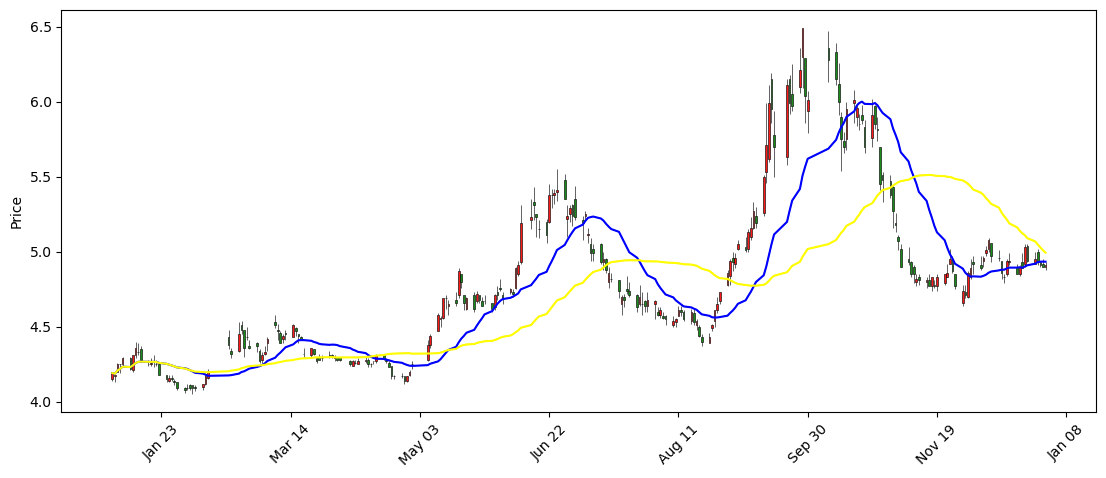

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance  as mpf
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

market_colors = mpf.make_marketcolors(up='red',down='green')
my_style = mpf.make_mpf_style(marketcolors = market_colors)
add_plots = [
    mpf.make_addplot(df['MA20'], color='blue', width=1.5),
    mpf.make_addplot(df['MA50'], color='yellow', width=1.5)
]

# 绘制K线图（需要OHLC数据）
mpf.plot(
    df,
    type='candle',
    figratio=(10, 4),
    mav = (ma_short_window,ma_long_window),
    show_nontrading=True,
    addplot=add_plots,
    style=my_style
)
mpf.show()

## 绘制交易信号图

In [38]:
df

,Open,High,Low,Close,前收盘价,涨跌额,涨跌幅(%),成交量(手),成交额(千元),MA20,MA50,Buy_Signal,Sell_Signal,Position,Total_Value_Change,Daily_Return,Cumulative_Return
Date,,,,,,,,,,,,,,,,,
2021-01-04,4.15,4.20,4.14,4.19,4.15,0.04,0.9639,969071.13,403962.846,4.190000,4.190000,False,False,0,0.0,0.0,1.0
2021-01-05,4.17,4.18,4.13,4.18,4.19,-0.01,-0.2387,818516.11,340130.522,4.185000,4.185000,False,False,0,0.0,0.0,1.0
2021-01-06,4.20,4.26,4.20,4.25,4.18,0.07,1.6746,1386651.56,587466.028,4.206667,4.206667,True,False,100,425.0,0.0,1.0
2021-01-07,4.25,4.25,4.19,4.25,4.25,0.00,0.0000,1130851.33,478465.595,4.217500,4.217500,False,False,0,0.0,-1.0,0.0
2021-01-08,4.25,4.30,4.24,4.29,4.25,0.04,0.9412,1524212.90,653176.211,4.232000,4.232000,False,False,0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,4.92,5.00,4.92,4.95,4.94,0.01,0.2024,773640.82,383846.871,4.919000,5.067600,False,False,0,0.0,0.0,-0.0
2021-12-28,5.00,5.02,4.91,4.93,4.95,-0.02,-0.4040,1143253.69,565165.071,4.930000,5.047000,False,False,0,0.0,0.0,-0.0
2021-12-29,4.93,4.94,4.90,4.91,4.93,-0.02,-0.4057,751128.09,369162.142,4.932500,5.028200,False,False,0,0.0,0.0,-0.0


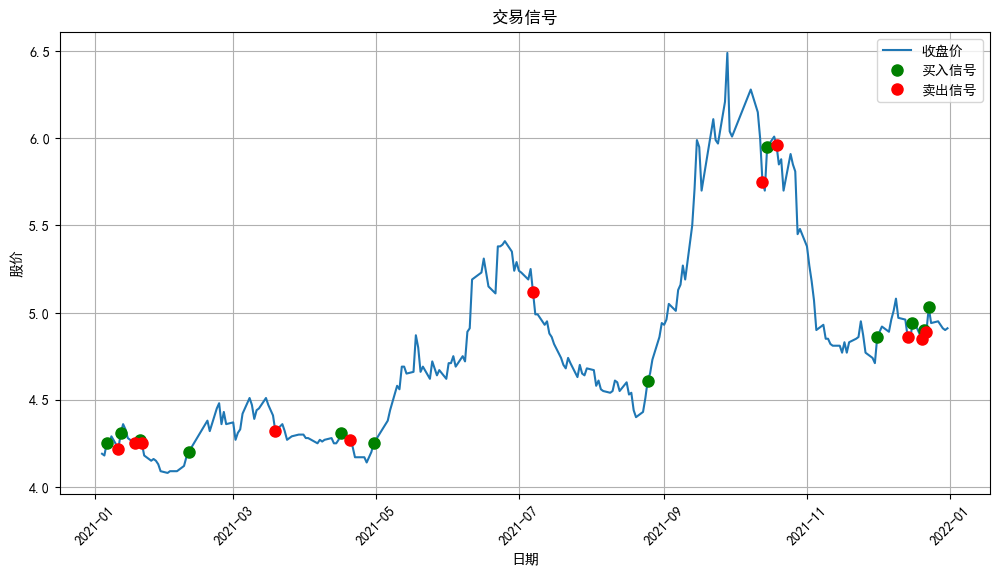

In [39]:
import matplotlib.pyplot as plt
# 设置中文显示
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# 绘制图形
plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='收盘价')  # 使用索引作为x轴（日期）
plt.plot(df.loc[df['Buy_Signal'],'Close'],'o',markersize=8,color='g',label='买入信号')
plt.plot(df.loc[df['Sell_Signal'],'Close'],'o',markersize=8,color='r',label='卖出信号')
plt.title('交易信号')
plt.xlabel('日期')
plt.ylabel('股价')  # 修正了拼写错误
plt.legend()
plt.grid(True)
plt.xticks(rotation = 45)
# 自动调整日期标签的显示格式，避免重叠

plt.show()